In [4]:
import os
import torch
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root='data/Planetoid', name='Cora', transform=NormalizeFeatures())

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]

print()
print(data)
print('===========================================================================================================')

print(f'Numer of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}') # 전체 2,708개 노드 중 학습에 사용하느 노드가 각 7개의 클래스들 중 20개 씩
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: Cora():
Number of graphs: 1
Number of features: 1433
Number of classes: 7

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Numer of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Training node label rate: 0.05
Has isolated: False
Has self-loops: False
Is undirected: True


In [15]:
from torch.nn import Linear
import torch.nn.functional as F

class MLP(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(42)
        self.lin1 = Linear(dataset.num_features, hidden_channels)
        self.lin2 = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x):
        x = self.lin1(x)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin2(x)
        return x
    
model = MLP(hidden_channels=16)
print(model)

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)


In [20]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()

    out = model(data.x)
    # Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
    # 여기서 data.x는 학습+검증+테스트 노드들의 특징 행렬
    # data.y는 노드의 정답 레이블

    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
    model.eval()
    out = model(data.x)
    pred = out.argmax(dim=1) # 가장 높은 확률에 속하는 클래스 사용
    test_correct = pred[data.test_mask] == data.y[data.test_mask] # pred된 노드, ground truth 노드 (같은 노드에 한해) 비교
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

for epoch in range(1, 200+1):
    loss = train()
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')


Epoch: 001, Loss: 0.4475
Epoch: 002, Loss: 0.4317
Epoch: 003, Loss: 0.4211
Epoch: 004, Loss: 0.4307
Epoch: 005, Loss: 0.4606
Epoch: 006, Loss: 0.4469
Epoch: 007, Loss: 0.4105
Epoch: 008, Loss: 0.4586
Epoch: 009, Loss: 0.3828
Epoch: 010, Loss: 0.4974
Epoch: 011, Loss: 0.4212
Epoch: 012, Loss: 0.3729
Epoch: 013, Loss: 0.4117
Epoch: 014, Loss: 0.4233
Epoch: 015, Loss: 0.3799
Epoch: 016, Loss: 0.4166
Epoch: 017, Loss: 0.4936
Epoch: 018, Loss: 0.4186
Epoch: 019, Loss: 0.4256
Epoch: 020, Loss: 0.4322
Epoch: 021, Loss: 0.3995
Epoch: 022, Loss: 0.3752
Epoch: 023, Loss: 0.3776
Epoch: 024, Loss: 0.3657
Epoch: 025, Loss: 0.3182
Epoch: 026, Loss: 0.4223
Epoch: 027, Loss: 0.4237
Epoch: 028, Loss: 0.3915
Epoch: 029, Loss: 0.4184
Epoch: 030, Loss: 0.3629
Epoch: 031, Loss: 0.3984
Epoch: 032, Loss: 0.3604
Epoch: 033, Loss: 0.3792
Epoch: 034, Loss: 0.4286
Epoch: 035, Loss: 0.3688
Epoch: 036, Loss: 0.3792
Epoch: 037, Loss: 0.4231
Epoch: 038, Loss: 0.3053
Epoch: 039, Loss: 0.3494
Epoch: 040, Loss: 0.4249


In [21]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.5720


In [ ]:
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        # MLP는 각 노드를 개별적으로 처리 -> 노드들 간의 연결과 상관없이 feature만 있으면 됨.
        # GCN은 이웃 노드 정보를 집계 -> Message Passing
        # edge_index는 누가 누구와 연결되어 있는가를 알기 위함
        x = self.conv1(x, edge_index)

        x = x.relu() # 직선이 아닌 꺾인 형태로
        x = F.dropout(x, p=0.5, training=self.training) # 학습 중에 node featuredml 50%를 랜덤하게 0으로 만드는 정규화

        x = self.conv2(x, edge_index)
        return x
    
model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)


In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

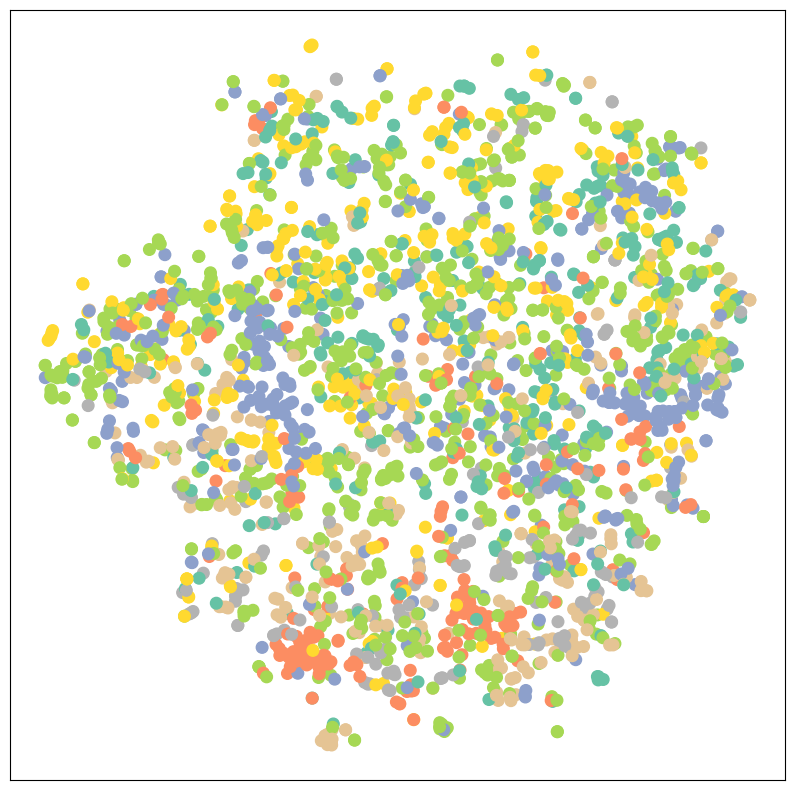

In [24]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

for epoch in range(1, 100+1):
    loss = train()
    print(f'Epoch: {epoch}, Loss: {loss:.4f}')

Epoch: 1, Loss: 0.5530
Epoch: 2, Loss: 0.5322
Epoch: 3, Loss: 0.5483
Epoch: 4, Loss: 0.5744
Epoch: 5, Loss: 0.5263
Epoch: 6, Loss: 0.5519
Epoch: 7, Loss: 0.5156
Epoch: 8, Loss: 0.5216
Epoch: 9, Loss: 0.5173
Epoch: 10, Loss: 0.5156
Epoch: 11, Loss: 0.5037
Epoch: 12, Loss: 0.5154
Epoch: 13, Loss: 0.4544
Epoch: 14, Loss: 0.5100
Epoch: 15, Loss: 0.4901
Epoch: 16, Loss: 0.4556
Epoch: 17, Loss: 0.4882
Epoch: 18, Loss: 0.4640
Epoch: 19, Loss: 0.4780
Epoch: 20, Loss: 0.4617
Epoch: 21, Loss: 0.4931
Epoch: 22, Loss: 0.4485
Epoch: 23, Loss: 0.4493
Epoch: 24, Loss: 0.4657
Epoch: 25, Loss: 0.4568
Epoch: 26, Loss: 0.4518
Epoch: 27, Loss: 0.4630
Epoch: 28, Loss: 0.4222
Epoch: 29, Loss: 0.4045
Epoch: 30, Loss: 0.4182
Epoch: 31, Loss: 0.4116
Epoch: 32, Loss: 0.3959
Epoch: 33, Loss: 0.4377
Epoch: 34, Loss: 0.4243
Epoch: 35, Loss: 0.4084
Epoch: 36, Loss: 0.4452
Epoch: 37, Loss: 0.4556
Epoch: 38, Loss: 0.4462
Epoch: 39, Loss: 0.4324
Epoch: 40, Loss: 0.3832
Epoch: 41, Loss: 0.3878
Epoch: 42, Loss: 0.3692
E

In [29]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.7970


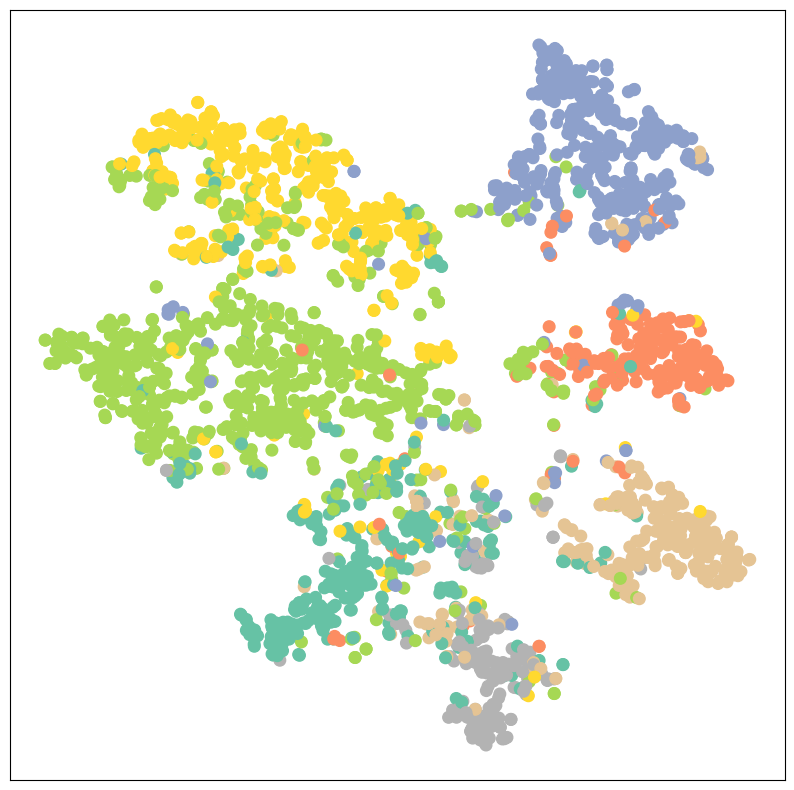

In [30]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [35]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = GATConv(dataset.num_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, heads)

    def forward(self, x, edge_index):

        x = F.dropout(x, p=0.6, training=self.training)
        # GAT 논문에서 conv1 이전에 dropout을 적용하는게 표준 방식(?)
        # Cora의 학습 데이터가 극히 적기 때문에 과적합을 막기 위해 입력 feature에 dropout을 적용하는 방식 채택

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x
    
model = GAT(hidden_channels=8, heads=8)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss

def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[mask] == data.y[mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

for epoch in range(1, 200+1):
    loss = train()
    val_acc = test(data.val_mask)
    test_acc = test(data.test_mask)
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}')

GAT(
  (conv1): GATConv(1433, 8, heads=1)
  (conv2): GATConv(8, 8, heads=1)
)
Epoch: 001, Loss: 2.0793, Val: 0.0800, Test: 0.1650
Epoch: 002, Loss: 2.0728, Val: 0.1050, Test: 0.2350
Epoch: 003, Loss: 2.0692, Val: 0.1190, Test: 0.2560
Epoch: 004, Loss: 2.0642, Val: 0.1260, Test: 0.2660
Epoch: 005, Loss: 2.0611, Val: 0.1290, Test: 0.2710
Epoch: 006, Loss: 2.0543, Val: 0.1270, Test: 0.2690
Epoch: 007, Loss: 2.0469, Val: 0.1260, Test: 0.2740
Epoch: 008, Loss: 2.0434, Val: 0.1280, Test: 0.2760
Epoch: 009, Loss: 2.0402, Val: 0.1250, Test: 0.2760
Epoch: 010, Loss: 2.0295, Val: 0.1240, Test: 0.2740
Epoch: 011, Loss: 2.0315, Val: 0.1260, Test: 0.2790
Epoch: 012, Loss: 2.0241, Val: 0.1240, Test: 0.2810
Epoch: 013, Loss: 2.0089, Val: 0.1240, Test: 0.2810
Epoch: 014, Loss: 2.0131, Val: 0.1240, Test: 0.2850
Epoch: 015, Loss: 2.0035, Val: 0.1230, Test: 0.2800
Epoch: 016, Loss: 1.9973, Val: 0.1230, Test: 0.2810
Epoch: 017, Loss: 1.9964, Val: 0.1230, Test: 0.2840
Epoch: 018, Loss: 1.9996, Val: 0.1240,

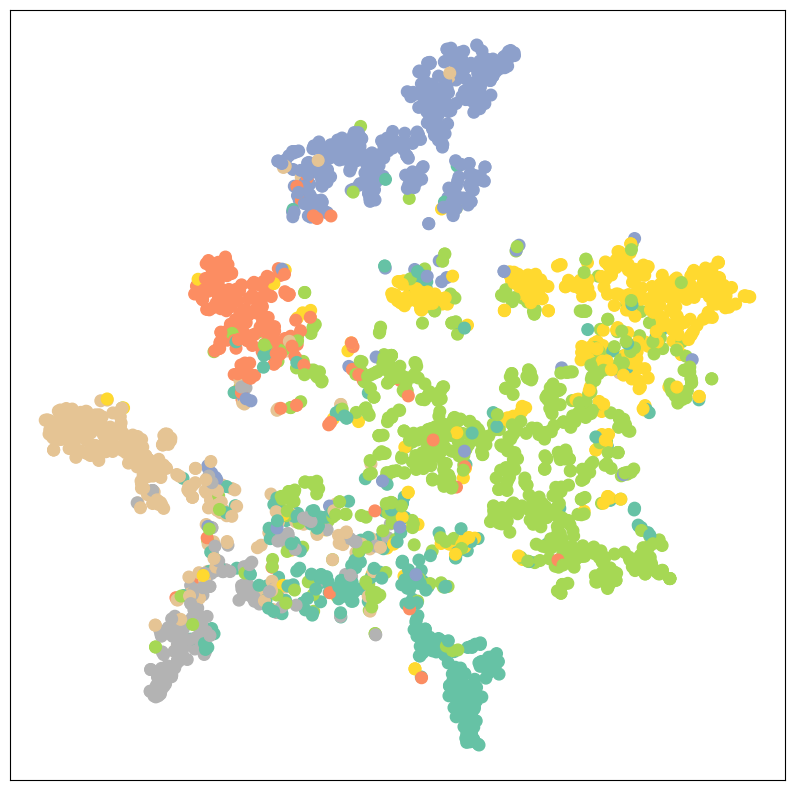

In [36]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)